# U-Net Baseline — Google Colab (A100, 512×512)

**Drive layout** (same as `WWR_Seg_Model.ipynb`):

| Path | Content |
|------|----------|
| `My Drive/WWR_Seg_Model/data.zip` | Training data |
| `/content/data/` | Local cache (fast I/O) |
| `My Drive/WWR_Seg_Model/models/` | Saved models |
| `My Drive/WWR_Seg_Model/results/unet/` | Plots & outputs |

1. **Runtime → A100 GPU**
2. Run all cells in order


In [1]:
!pip install -q tensorflow>=2.15 opencv-python-headless scikit-learn tqdm matplotlib


In [2]:
import os
import shutil
import zipfile
from pathlib import Path

from google.colab import drive

if not Path('/content/drive/MyDrive').exists():
    drive.mount('/content/drive')

DRIVE_BASE = Path('/content/drive/MyDrive/WWR_Seg_Model')
DATA_ZIP = DRIVE_BASE / 'data.zip'
LOCAL_DATA = Path('/content/data')
MODELS_DIR = DRIVE_BASE / 'models'
RESULTS_DIR = DRIVE_BASE / 'results' / 'unet'

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('Drive base :', DRIVE_BASE)
print('Data zip   :', DATA_ZIP, '→', DATA_ZIP.exists())


Mounted at /content/drive
Drive base : /content/drive/MyDrive/WWR_Seg_Model
Data zip   : /content/drive/MyDrive/WWR_Seg_Model/data.zip → True


In [3]:
IMAGE_EXTS = {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}


def _count_images(folder: Path) -> int:
    return sum(1 for f in folder.iterdir() if f.suffix.lower() in IMAGE_EXTS)


def prepare_local_data(force: bool = False) -> tuple[Path, Path]:
    """Unzip data.zip to /content/data and normalize to train/images + train/masks."""
    train_img = LOCAL_DATA / 'train' / 'images'
    train_msk = LOCAL_DATA / 'train' / 'masks'
    if not force and train_img.exists() and _count_images(train_img) > 0:
        print('Using cached local data:', train_img)
        return train_img, train_msk

    if not DATA_ZIP.exists():
        raise FileNotFoundError(f'Upload data.zip to {DATA_ZIP}')

    tmp = LOCAL_DATA / '_zip_extract'
    if tmp.exists():
        shutil.rmtree(tmp)
    tmp.mkdir(parents=True)

    print('Extracting', DATA_ZIP)
    with zipfile.ZipFile(DATA_ZIP, 'r') as zf:
        zf.extractall(tmp)

    flat_img = tmp / 'images'
    flat_msk = tmp / 'masks'
    if flat_img.exists() and flat_msk.exists():
        train_img.parent.mkdir(parents=True, exist_ok=True)
        if LOCAL_DATA.exists():
            shutil.rmtree(LOCAL_DATA / 'train', ignore_errors=True)
        shutil.copytree(flat_img, train_img)
        shutil.copytree(flat_msk, train_msk)
    elif (tmp / 'train' / 'images').exists():
        if LOCAL_DATA.exists():
            shutil.rmtree(LOCAL_DATA, ignore_errors=True)
        shutil.copytree(tmp, LOCAL_DATA)
    else:
        raise FileNotFoundError('Expected images/ + masks/ or train/images inside data.zip')

    shutil.rmtree(tmp, ignore_errors=True)
    print('Train images:', _count_images(train_img))
    return train_img, train_msk


images_dir, masks_dir = prepare_local_data(force=False)
print('Images:', images_dir)
print('Masks :', masks_dir)


Extracting /content/drive/MyDrive/WWR_Seg_Model/data.zip
Train images: 1000
Images: /content/data/train/images
Masks : /content/data/train/masks


In [4]:
import glob
import cv2
import numpy as np
import tqdm
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import Model, Input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    BatchNormalization, Concatenate, Conv2D, Conv2DTranspose, Dropout,
)
from tensorflow.keras.metrics import MeanIoU
from tensorflow.keras.utils import to_categorical

OUTPUT_CHANNELS = 4
SIZE_X = 512
SIZE_Y = 512
MASK_LUT = {72: 0, 128: 1, 220: 2, 255: 3}  # Roof, Window, Wall, Other


def pair_image_mask_paths(img_dir: Path, mask_dir: Path) -> list[tuple[str, str]]:
    pairs = []
    for img_path in sorted(img_dir.iterdir()):
        if img_path.suffix.lower() not in {'.png', '.jpg', '.jpeg'}:
            continue
        stem = img_path.stem
        mask_stem = stem.replace('_texture', '_mask') if stem.endswith('_texture') else f'{stem}_mask'
        mask_path = mask_dir / f'{mask_stem}{img_path.suffix}'
        if not mask_path.exists():
            raise FileNotFoundError(f'No mask for {img_path.name}')
        pairs.append((str(img_path), str(mask_path)))
    return pairs


def standardize(x):
    x = np.array(x, dtype='float32')
    x -= np.min(x)
    denom = np.percentile(x, 98)
    x /= denom if denom > 0 else 1.0
    x[x > 1] = 1
    return x


def preprocessing(img):
    image = np.array(img)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    image = np.stack([gray, gray, gray], axis=-1)
    return standardize(image)


pairs = pair_image_mask_paths(images_dir, masks_dir)
print(f'Paired samples: {len(pairs)}')
print('First pair:', pairs[0])


Paired samples: 1000
First pair: ('/content/data/train/images/45.3677_-74.0326_texture.png', '/content/data/train/masks/45.3677_-74.0326_mask.png')


In [5]:
train_images, train_masks = [], []

for img_path, mask_path in tqdm.tqdm(pairs, desc='Loading'):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (SIZE_X, SIZE_Y))
    train_images.append(preprocessing(img))

    mask0 = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask1 = cv2.resize(mask0, (SIZE_X, SIZE_Y), interpolation=cv2.INTER_NEAREST)
    for old_val, new_val in MASK_LUT.items():
        mask1[mask1 == old_val] = new_val
    train_masks.append(mask1)

train_images = np.array(train_images, dtype=np.float32)
train_masks = np.array(train_masks, dtype=np.int32)

X_train, X_val, y_train, y_val = train_test_split(
    train_images, train_masks, test_size=0.10, random_state=42, shuffle=True
)
print('Train:', len(X_train), '| Val:', len(X_val))
print('Classes:', np.unique(y_train))

y_train = to_categorical(y_train, num_classes=OUTPUT_CHANNELS)
y_val = to_categorical(y_val, num_classes=OUTPUT_CHANNELS)


Loading: 100%|██████████| 1000/1000 [00:20<00:00, 47.75it/s]


Train: 900 | Val: 100
Classes: [0 1 2 3]


In [6]:
def augment(image, mask):
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, mask


def build_dataset(X, Y, training=True, batch_size=8):
    ds = tf.data.Dataset.from_tensor_slices((X, Y))
    if training:
        ds = ds.shuffle(len(X)).map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


In [7]:
def upsample_with_dropout(filters, size, dropout_rate=0.2):
    return tf.keras.Sequential([
        Conv2DTranspose(filters, size, strides=2, padding='same', use_bias=False),
        BatchNormalization(),
        Dropout(dropout_rate),
        tf.keras.layers.ReLU(),
    ])


def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1, OUTPUT_CHANNELS])
    y_pred_f = tf.reshape(y_pred, [-1, OUTPUT_CHANNELS])
    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
    denominator = tf.reduce_sum(y_true_f, axis=0) + tf.reduce_sum(y_pred_f, axis=0)
    dice = (2.0 * intersection + smooth) / (denominator + smooth)
    return 1.0 - tf.reduce_mean(dice)


def combined_loss(y_true, y_pred):
    cce = tf.keras.losses.CategoricalCrossentropy()(y_true, y_pred)
    return cce + dice_loss(y_true, y_pred)


def unet_model(output_channels=4, dropout_rate=0.2, fine_tune_at=100):
    h, w, c = X_train.shape[1:]
    base = MobileNetV2(input_shape=[h, w, c], include_top=False, weights='imagenet')
    layer_names = [
        'block_1_expand_relu', 'block_3_expand_relu', 'block_6_expand_relu',
        'block_13_expand_relu', 'block_16_project',
    ]
    down_stack = Model(base.input, [base.get_layer(n).output for n in layer_names])
    for layer in down_stack.layers:
        layer.trainable = False
    for layer in down_stack.layers[fine_tune_at:]:
        layer.trainable = True

    up_stack = [
        upsample_with_dropout(512, 3, dropout_rate),
        upsample_with_dropout(256, 3, dropout_rate),
        upsample_with_dropout(128, 3, dropout_rate),
        upsample_with_dropout(64, 3, dropout_rate),
    ]
    inputs = Input(shape=[h, w, c])
    skips = down_stack(inputs)
    x = skips[-1]
    for up, skip in zip(up_stack, reversed(skips[:-1])):
        x = up(x)
        x = Concatenate()([x, skip])
    outputs = Conv2DTranspose(output_channels, 3, strides=2, padding='same', activation='softmax')(x)
    return Model(inputs, outputs)


In [8]:
def create_mask(pred_mask):
    return tf.argmax(pred_mask, axis=-1)[0].numpy()


def show_predictions(epoch, sample_idx=50):
    fig = plt.figure(figsize=(12, 4))
    for col, (title, arr) in enumerate([
        ('Input', X_val[sample_idx]),
        ('Ground Truth', np.argmax(y_val[sample_idx], axis=-1)),
        ('Prediction', create_mask(model.predict(X_val[sample_idx:sample_idx+1], verbose=0))),
    ]):
        ax = fig.add_subplot(1, 3, col + 1)
        ax.imshow(arr if col == 0 else arr, cmap=None if col == 0 else 'jet')
        ax.set_title(title)
        ax.axis('off')
    fig.suptitle(f'Epoch {epoch + 1}')
    out = RESULTS_DIR / f'epoch_{epoch + 1:03d}.png'
    fig.savefig(out, dpi=100, bbox_inches='tight')
    plt.show()


class DisplayCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        show_predictions(epoch)


In [9]:
model = unet_model(OUTPUT_CHANNELS, dropout_rate=0.2, fine_tune_at=100)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=['accuracy', MeanIoU(num_classes=OUTPUT_CHANNELS)],
)
model.summary()


/tmp/ipykernel_474/263637982.py:26: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(input_shape=[h, w, c], include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, 256, 256, │  1,841,984 │ input_layer_1[0]… │
│ (Functional)        │ 96), (None, 128,  │            │                   │
│                     │ 128, 144), (None, │            │                   │
│                     │ 64, 64, 192),     │            │                   │
│                     │ (None, 32, 32,    │            │                   │
│                     │ 576), (None, 16,  │            │                   │
│                     │ 16, 320)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 32, 32,    │  1,476,608 │ functional[0][4]  │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ sequential[0][0], │
│ (Concatenate)       │ 1088)             │            │ functional[0][3]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 64, 64,    │  2,507,776 │ concatenate[0][0] │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64, 64,    │          0 │ sequential_1[0][… │
│ (Concatenate)       │ 448)              │            │ functional[0][2]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 128, 128,  │    516,608 │ concatenate_1[0]… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 128, 128,  │          0 │ sequential_2[0][… │
│ (Concatenate)       │ 272)              │            │ functional[0][1]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 256, 256,  │    156,928 │ concatenate_2[0]… │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 256, 256,  │          0 │ sequential_3[0][… │
│ (Concatenate)       │ 160)              │            │ functional[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 512, 512,  │      5,764 │ concatenate_3[0]… │
│ (Conv2DTranspose)   │ 4)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,505,668 (24.82 MB)

 Trainable params: 6,110,404 (23.31 MB)

 Non-trainable params: 395,264 (1.51 MB)

Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.5189 - loss: 1.9825 - mean_io_u: 0.3750

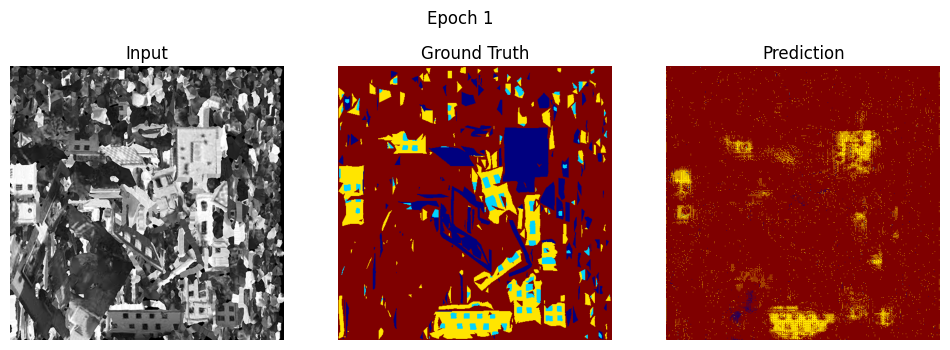


Epoch 1: val_loss improved from None to 1.60033, saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_baseline.keras

Epoch 1: finished saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_baseline.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 133s 652ms/step - accuracy: 0.6115 - loss: 1.7396 - mean_io_u: 0.3750 - val_accuracy: 0.6722 - val_loss: 1.6003 - val_mean_io_u: 0.3750
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7213 - loss: 1.3990 - mean_io_u: 0.3750

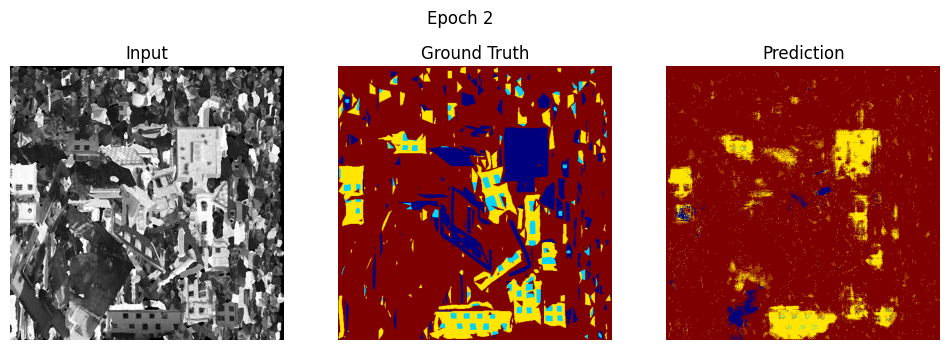


Epoch 2: val_loss improved from 1.60033 to 1.43268, saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_baseline.keras

Epoch 2: finished saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_baseline.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.7251 - loss: 1.3726 - mean_io_u: 0.3750 - val_accuracy: 0.7116 - val_loss: 1.4327 - val_mean_io_u: 0.3750
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7436 - loss: 1.2790 - mean_io_u: 0.3750

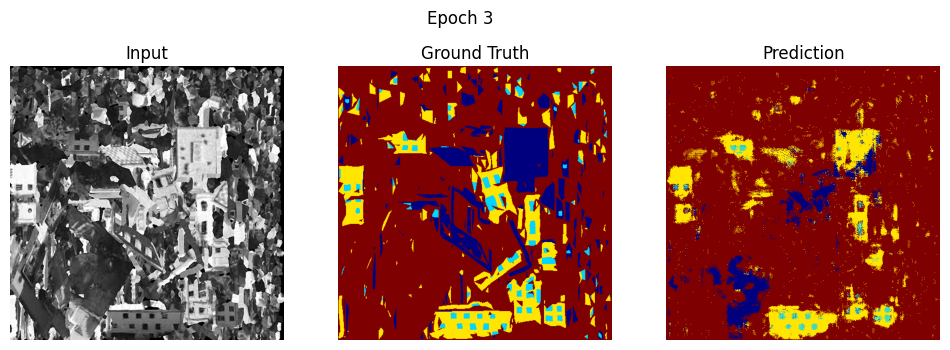


Epoch 3: val_loss improved from 1.43268 to 1.36389, saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_baseline.keras

Epoch 3: finished saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_baseline.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.7445 - loss: 1.2634 - mean_io_u: 0.3750 - val_accuracy: 0.7106 - val_loss: 1.3639 - val_mean_io_u: 0.3750
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7568 - loss: 1.1960 - mean_io_u: 0.3750

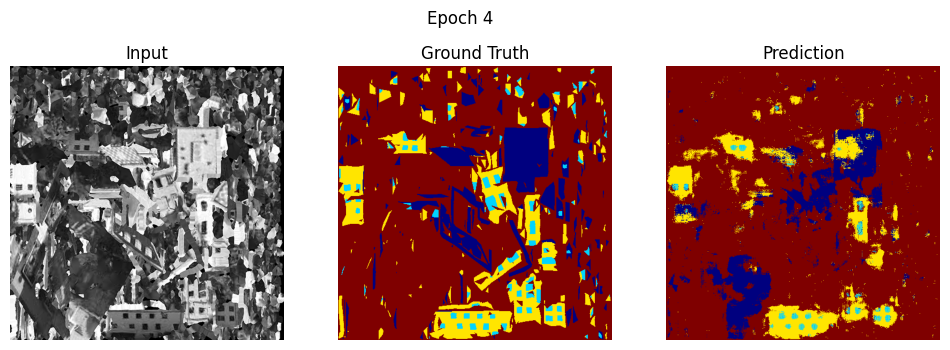


Epoch 4: val_loss improved from 1.36389 to 1.30093, saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_baseline.keras

Epoch 4: finished saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_baseline.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.7572 - loss: 1.1881 - mean_io_u: 0.3750 - val_accuracy: 0.7237 - val_loss: 1.3009 - val_mean_io_u: 0.3750
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7670 - loss: 1.1409 - mean_io_u: 0.3750

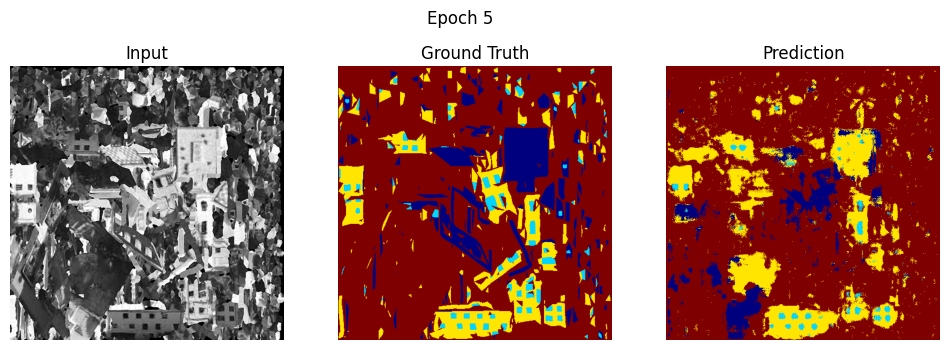


Epoch 5: val_loss did not improve from 1.30093
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.7662 - loss: 1.1397 - mean_io_u: 0.3750 - val_accuracy: 0.7023 - val_loss: 1.3275 - val_mean_io_u: 0.3750
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7718 - loss: 1.1107 - mean_io_u: 0.3750

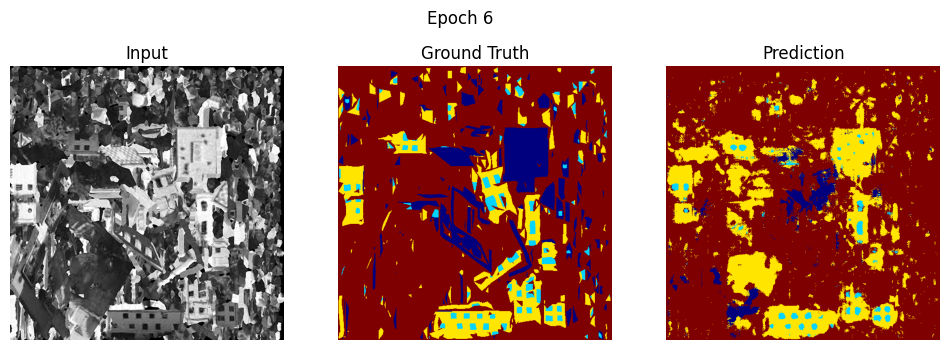


Epoch 6: val_loss improved from 1.30093 to 1.28685, saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_baseline.keras

Epoch 6: finished saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_baseline.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.7720 - loss: 1.1068 - mean_io_u: 0.3750 - val_accuracy: 0.7141 - val_loss: 1.2869 - val_mean_io_u: 0.3750
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7777 - loss: 1.0789 - mean_io_u: 0.3750

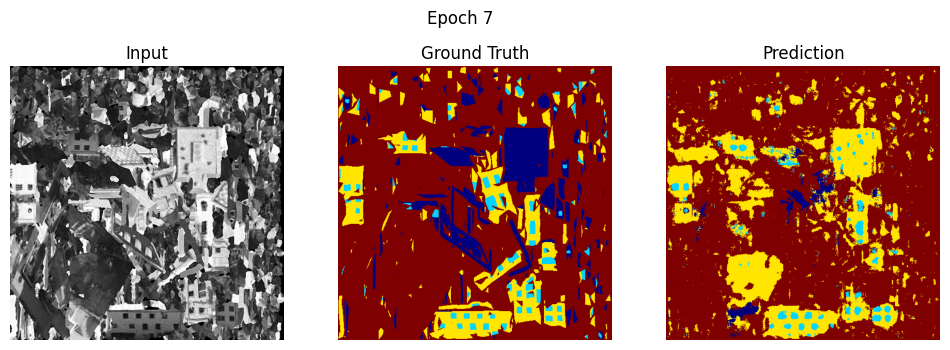


Epoch 7: val_loss did not improve from 1.28685
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.7788 - loss: 1.0751 - mean_io_u: 0.3750 - val_accuracy: 0.7070 - val_loss: 1.2971 - val_mean_io_u: 0.3750
Epoch 8/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7856 - loss: 1.0493 - mean_io_u: 0.3750

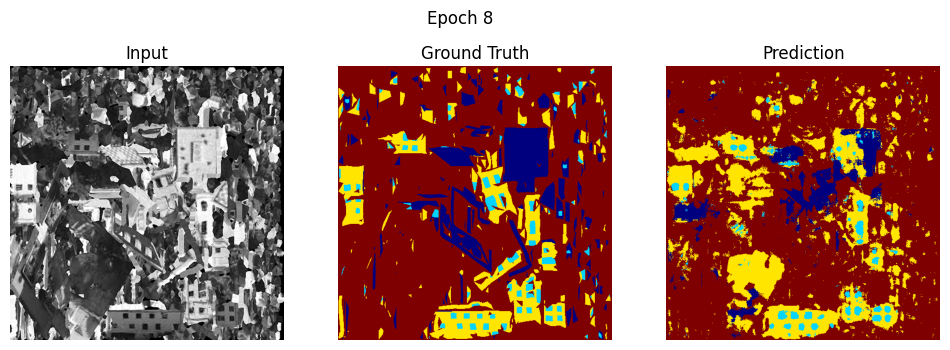


Epoch 8: val_loss did not improve from 1.28685
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.7825 - loss: 1.0577 - mean_io_u: 0.3750 - val_accuracy: 0.6953 - val_loss: 1.3287 - val_mean_io_u: 0.3750
Epoch 9/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7871 - loss: 1.0336 - mean_io_u: 0.3750

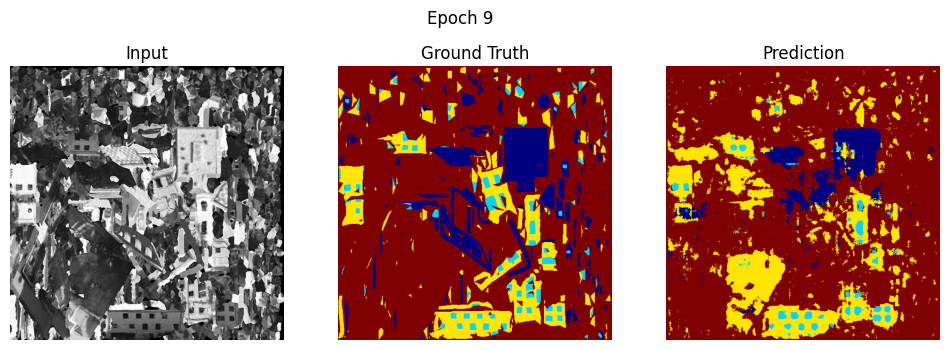


Epoch 9: val_loss improved from 1.28685 to 1.28487, saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_baseline.keras

Epoch 9: finished saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_baseline.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.7871 - loss: 1.0347 - mean_io_u: 0.3750 - val_accuracy: 0.7119 - val_loss: 1.2849 - val_mean_io_u: 0.3750
Epoch 10/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7892 - loss: 1.0213 - mean_io_u: 0.3750

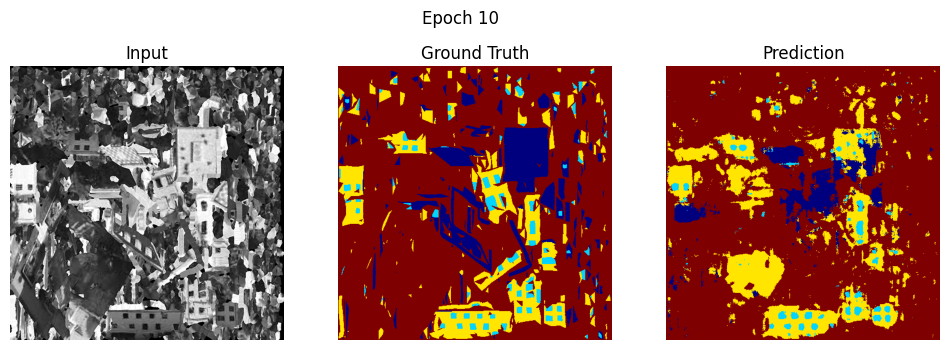


Epoch 10: val_loss improved from 1.28487 to 1.26109, saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_baseline.keras

Epoch 10: finished saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_baseline.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.7910 - loss: 1.0176 - mean_io_u: 0.3750 - val_accuracy: 0.7256 - val_loss: 1.2611 - val_mean_io_u: 0.3750
Epoch 11/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7916 - loss: 1.0147 - mean_io_u: 0.3750

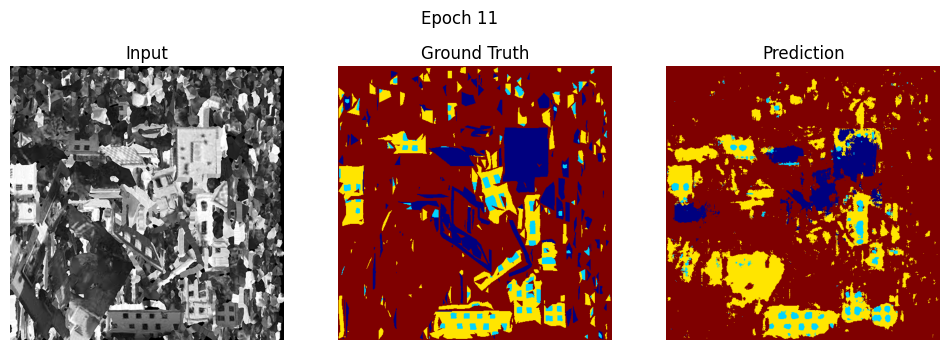


Epoch 11: val_loss improved from 1.26109 to 1.24820, saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_baseline.keras

Epoch 11: finished saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_baseline.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.7943 - loss: 1.0046 - mean_io_u: 0.3750 - val_accuracy: 0.7293 - val_loss: 1.2482 - val_mean_io_u: 0.3750
Epoch 12/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7988 - loss: 0.9796 - mean_io_u: 0.3750

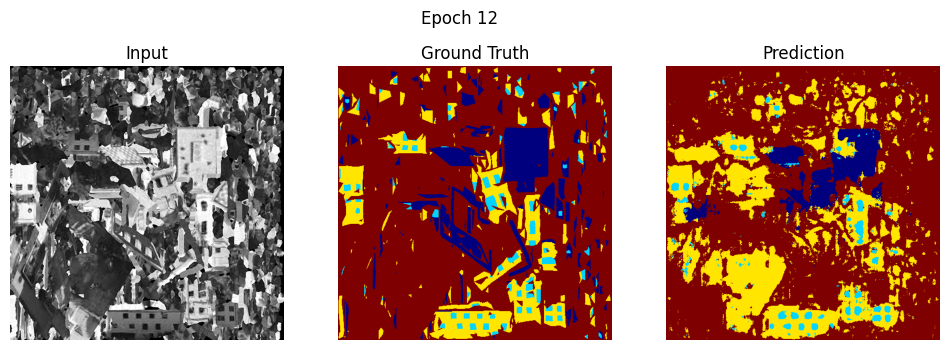


Epoch 12: val_loss did not improve from 1.24820
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.7977 - loss: 0.9863 - mean_io_u: 0.3750 - val_accuracy: 0.7070 - val_loss: 1.3101 - val_mean_io_u: 0.3750
Epoch 13/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8046 - loss: 0.9621 - mean_io_u: 0.3750

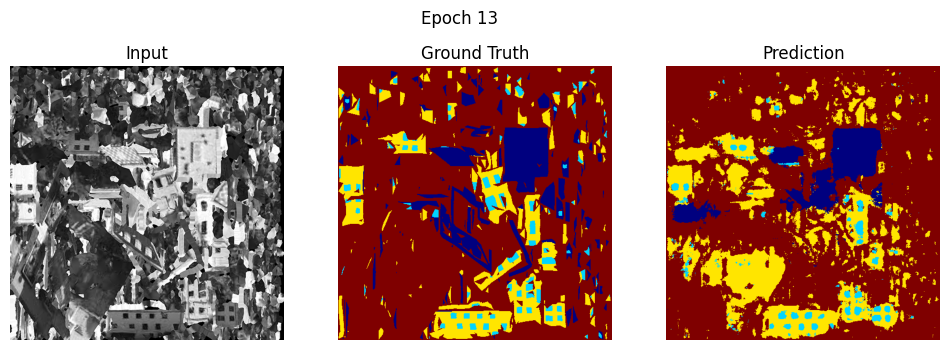


Epoch 13: val_loss did not improve from 1.24820
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.8003 - loss: 0.9757 - mean_io_u: 0.3750 - val_accuracy: 0.7151 - val_loss: 1.2895 - val_mean_io_u: 0.3750
Epoch 14/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7996 - loss: 0.9701 - mean_io_u: 0.3750

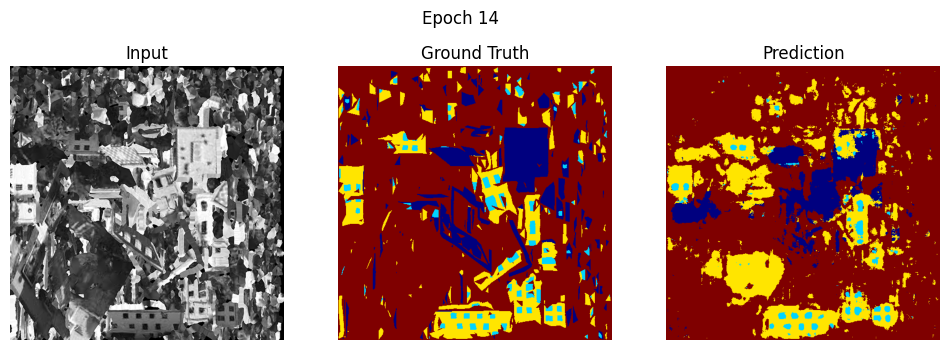


Epoch 14: val_loss did not improve from 1.24820
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.8026 - loss: 0.9646 - mean_io_u: 0.3750 - val_accuracy: 0.7219 - val_loss: 1.2796 - val_mean_io_u: 0.3750
Epoch 15/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8037 - loss: 0.9642 - mean_io_u: 0.3750

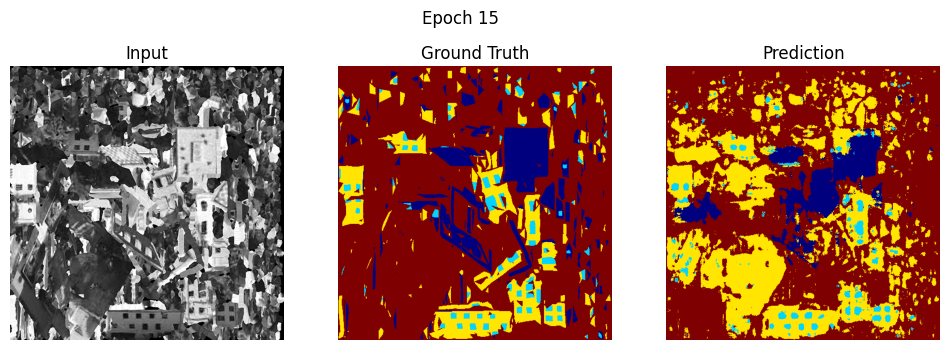


Epoch 15: val_loss did not improve from 1.24820
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.8044 - loss: 0.9572 - mean_io_u: 0.3750 - val_accuracy: 0.6944 - val_loss: 1.3529 - val_mean_io_u: 0.3750
Epoch 16/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8043 - loss: 0.9525 - mean_io_u: 0.3750

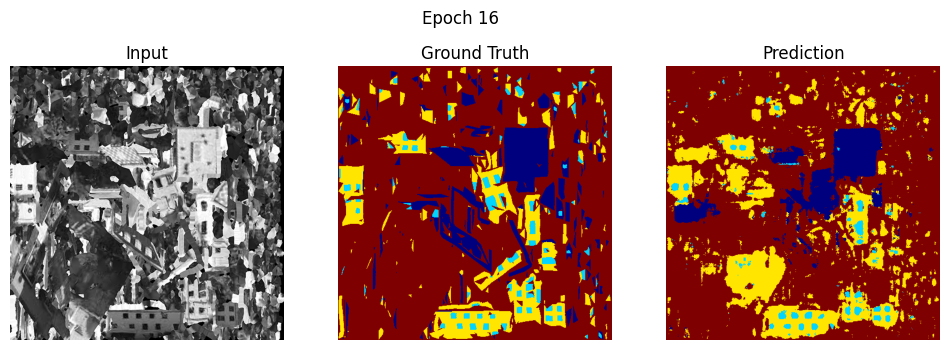


Epoch 16: val_loss improved from 1.24820 to 1.24013, saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_baseline.keras

Epoch 16: finished saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_baseline.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.8068 - loss: 0.9462 - mean_io_u: 0.3750 - val_accuracy: 0.7332 - val_loss: 1.2401 - val_mean_io_u: 0.3750
Epoch 17/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8099 - loss: 0.9411 - mean_io_u: 0.3750

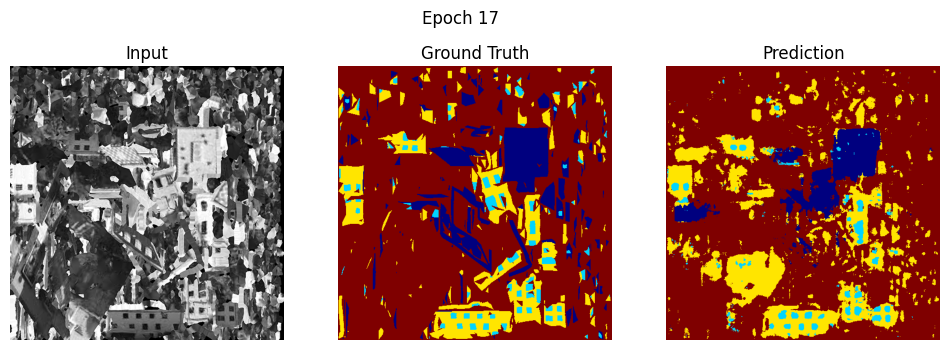


Epoch 17: val_loss did not improve from 1.24013
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.8088 - loss: 0.9369 - mean_io_u: 0.3750 - val_accuracy: 0.7347 - val_loss: 1.2444 - val_mean_io_u: 0.3750
Epoch 18/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8133 - loss: 0.9180 - mean_io_u: 0.3750

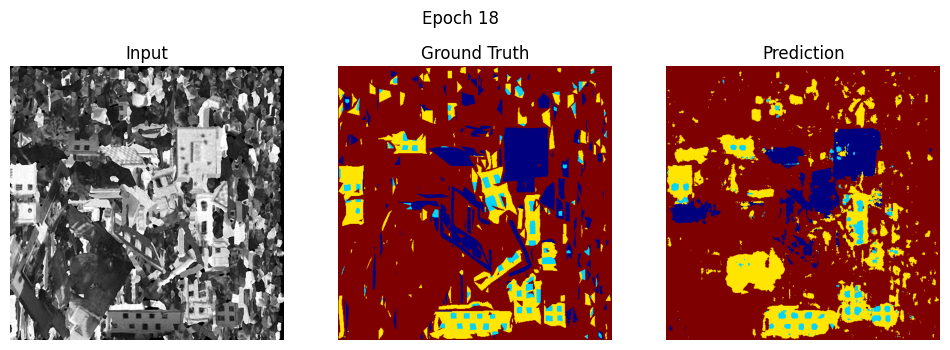


Epoch 18: val_loss did not improve from 1.24013
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.8105 - loss: 0.9283 - mean_io_u: 0.3750 - val_accuracy: 0.7365 - val_loss: 1.2402 - val_mean_io_u: 0.3750
Epoch 19/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8145 - loss: 0.9139 - mean_io_u: 0.3750

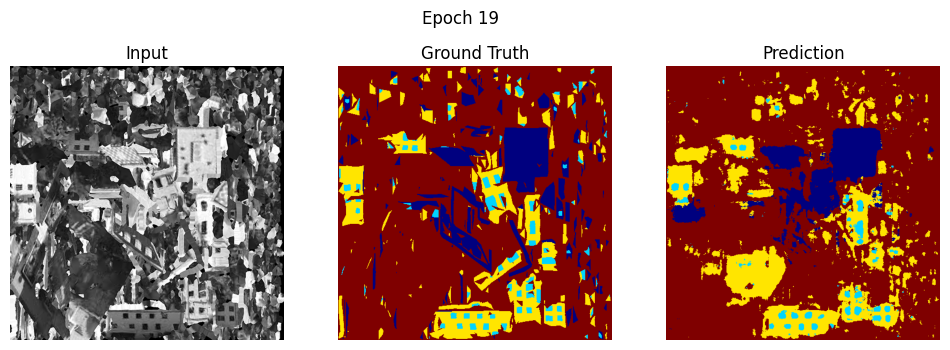


Epoch 19: val_loss did not improve from 1.24013
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.8129 - loss: 0.9171 - mean_io_u: 0.3750 - val_accuracy: 0.7351 - val_loss: 1.2528 - val_mean_io_u: 0.3750
Epoch 20/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8131 - loss: 0.9149 - mean_io_u: 0.3750

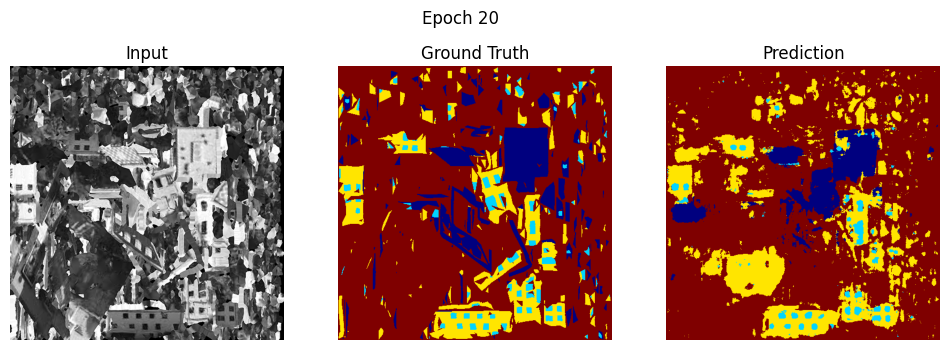


Epoch 20: val_loss did not improve from 1.24013
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.8148 - loss: 0.9100 - mean_io_u: 0.3750 - val_accuracy: 0.7303 - val_loss: 1.2778 - val_mean_io_u: 0.3750
Epoch 21/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8153 - loss: 0.9074 - mean_io_u: 0.3750

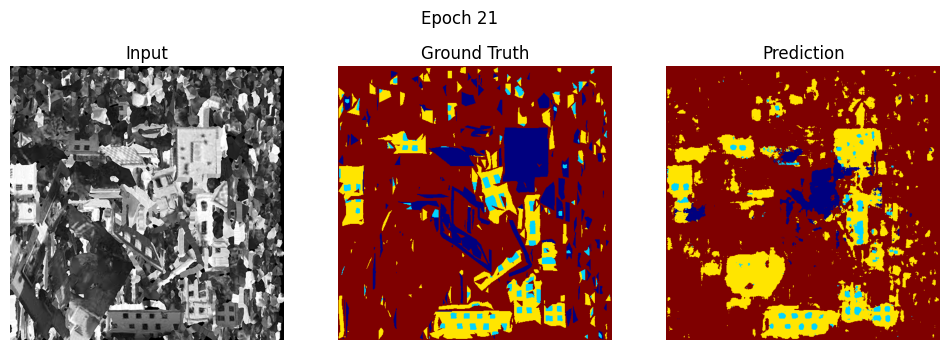


Epoch 21: val_loss did not improve from 1.24013
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.8156 - loss: 0.9048 - mean_io_u: 0.3750 - val_accuracy: 0.7294 - val_loss: 1.2824 - val_mean_io_u: 0.3750
Epoch 22/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8181 - loss: 0.8935 - mean_io_u: 0.3750

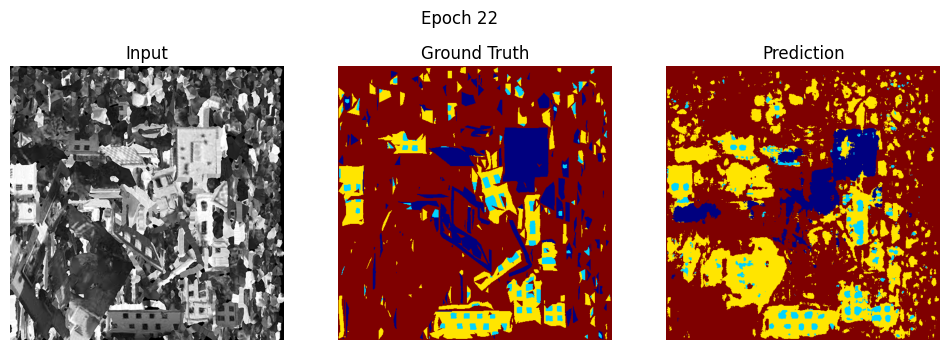


Epoch 22: val_loss did not improve from 1.24013
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.8173 - loss: 0.8967 - mean_io_u: 0.3750 - val_accuracy: 0.7153 - val_loss: 1.3202 - val_mean_io_u: 0.3750
Epoch 23/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8177 - loss: 0.8997 - mean_io_u: 0.3750

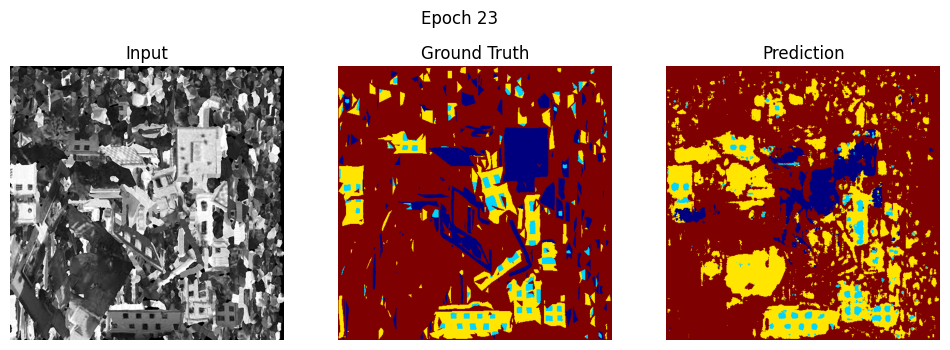


Epoch 23: val_loss did not improve from 1.24013
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.8178 - loss: 0.8953 - mean_io_u: 0.3750 - val_accuracy: 0.7277 - val_loss: 1.2773 - val_mean_io_u: 0.3750
Epoch 24/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8179 - loss: 0.8964 - mean_io_u: 0.3750

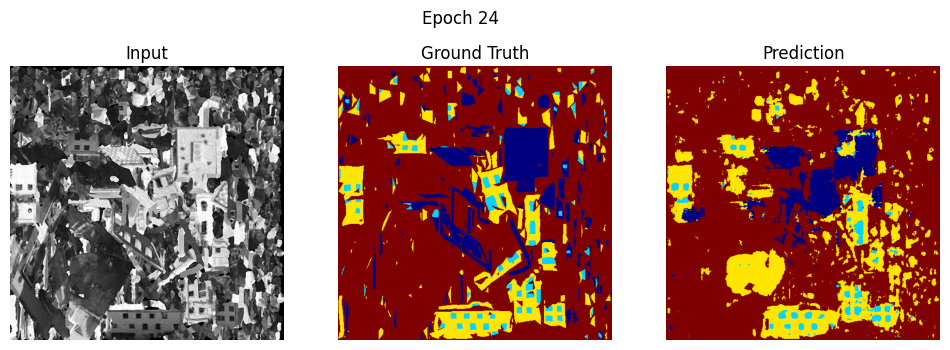


Epoch 24: val_loss did not improve from 1.24013
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.8198 - loss: 0.8859 - mean_io_u: 0.3750 - val_accuracy: 0.7358 - val_loss: 1.2579 - val_mean_io_u: 0.3750
Best model → /content/drive/MyDrive/WWR_Seg_Model/models/unet_baseline.keras


In [10]:
EPOCHS = 30
BATCH_SIZE = 8  # 512×512 on A100

train_ds = build_dataset(X_train, y_train, training=True, batch_size=BATCH_SIZE)
val_ds = build_dataset(X_val, y_val, training=False, batch_size=BATCH_SIZE)

checkpoint_path = MODELS_DIR / 'unet_baseline.keras'
callbacks = [
    DisplayCallback(),
    tf.keras.callbacks.ModelCheckpoint(
        str(checkpoint_path), monitor='val_loss', mode='min',
        save_best_only=True, verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
]

history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)
print('Best model →', checkpoint_path)


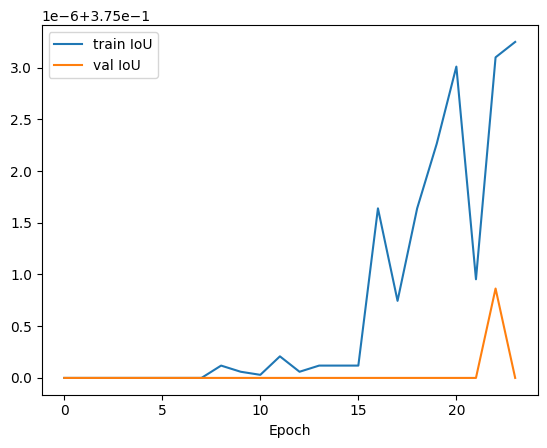

In [11]:
iou_key = 'mean_io_u' if 'mean_io_u' in history.history else 'mean_iou'
val_iou_key = 'val_' + iou_key
plt.plot(history.history[iou_key], label='train IoU')
plt.plot(history.history[val_iou_key], label='val IoU')
plt.xlabel('Epoch')
plt.legend()
plt.savefig(RESULTS_DIR / 'training_curve.png', dpi=120, bbox_inches='tight')
plt.show()


In [12]:
# Optional test images (upload to Drive when ready)
TEST_IMG_DIR = DRIVE_BASE / 'test_images' / 'final_images'

if TEST_IMG_DIR.exists():
    test_paths = sorted(TEST_IMG_DIR.glob('*.png'))
    print(f'Test images: {len(test_paths)}')
    img = cv2.imread(str(test_paths[0]))
    img = cv2.resize(img, (SIZE_X, SIZE_Y))
    img = preprocessing(img)
    pred = create_mask(model.predict(img[np.newaxis, ...], verbose=0))
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1); plt.imshow(img); plt.title('Input'); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(pred, cmap='jet'); plt.title('Prediction'); plt.axis('off')
    plt.savefig(RESULTS_DIR / 'test_sample.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('No test set yet →', TEST_IMG_DIR)


No test set yet → /content/drive/MyDrive/WWR_Seg_Model/test_images/final_images
